## Imports

In [228]:
import os
import torch
import json
from assignment9_functions import *


if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
    print("Apple GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU / AMD ROCm GPU
    print("Nvidia/AMD GPU")
else:
    device = torch.device("cpu")
    print("CPU")


random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

Apple GPU


## Load data and split

In [229]:
datafolder = "../../MainProject/Assignment9/data/kinect_good_preprocessed"

# Alt 1: 80/10/10 split
#train_files, val_files, test_files = split_csvfiles(datafolder, random_seed, 0.8, 0.1)
#val_data = load(val_files, datafolder)


# Alt 2: 90/10 since we don't need validation data if we run k-fold cv
train_files, test_files = split_csvfiles(datafolder, random_seed, 0.9, 0)

train_data = load(train_files, datafolder)
test_data = load(test_files, datafolder)
#val_data = load(val_files, datafolder)

print(train_data.columns.tolist())

['FrameNo', 'head_x', 'head_y', 'head_z', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'left_elbow_x', 'left_elbow_y', 'left_elbow_z', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z', 'right_elbow_x', 'right_elbow_y', 'right_elbow_z', 'left_hand_x', 'left_hand_y', 'left_hand_z', 'right_hand_x', 'right_hand_y', 'right_hand_z', 'left_hip_x', 'left_hip_y', 'left_hip_z', 'right_hip_x', 'right_hip_y', 'right_hip_z', 'left_knee_x', 'left_knee_y', 'left_knee_z', 'right_knee_x', 'right_knee_y', 'right_knee_z', 'left_foot_x', 'left_foot_y', 'left_foot_z', 'right_foot_x', 'right_foot_y', 'right_foot_z']


## Split data into input and target

In [230]:

x_train, y_train = input_target_split(train_data)
#x_val, y_val = input_target_split(val_data)
x_test, y_test = input_target_split(test_data)


print("Train:", x_train.shape, y_train.shape)
#print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)


# Convert to tensors
x_train = torch.tensor(x_train.values, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
#x_val = torch.tensor(x_val.values, dtype=torch.float32).to(device)
#y_val = torch.tensor(y_val.values, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test.values, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device)

Train: (21832, 26) (21832, 13)
Test: (2173, 26) (2173, 13)


## Define paths to stored champion model

In [231]:
model_root = "../models"
metadata_path = os.path.join(model_root, "metadata", "champion_info.json")
model_path = os.path.join(model_root, "champion", "champion_model.pt")


# Load config

In [232]:
with open(metadata_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]

print("Loaded champion config:")
print(best_config)


Loaded champion config:
{'hidden_layers': [256, 128, 64], 'learning_rate': 0.001, 'dropout': 0, 'activation': 'relu', 'optimizer': 'adam', 'epochs': 500, 'patience': 5}


# Build and retrain best model

In [233]:
best_model = build_model(best_config, device)

result = train_one_model(
    best_model,
    best_config,
    x_train,
    y_train,
    x_train,
    y_train,
)
best_model.load_state_dict(result["best_state"])


<All keys matched successfully>

# Evaluate

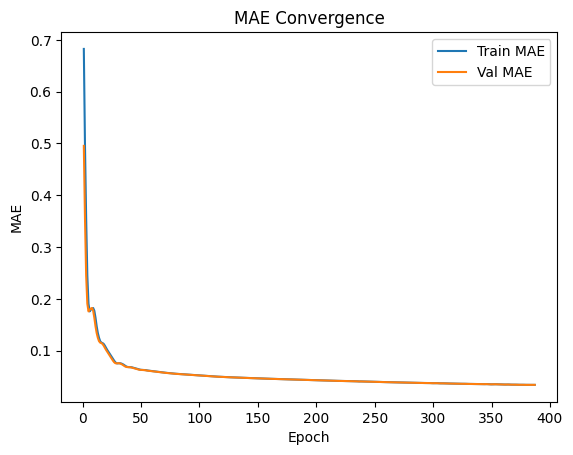

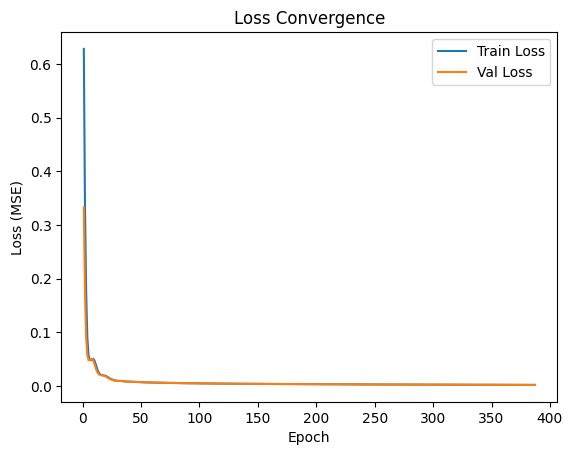

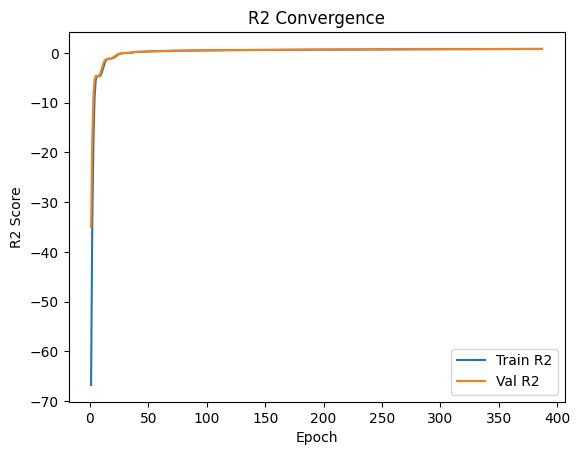

In [238]:
import matplotlib.pyplot as plt

history = result["history"]

epochs = [h["epoch"] for h in history]

# Extract metrics
train_mae = [h["train_mae"] for h in history]
val_mae = [h["val_mae"] for h in history]

train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]

train_r2 = [h["train_r2"] for h in history]
val_r2 = [h["val_r2"] for h in history]

# --- MAE ---
plt.figure()
plt.plot(epochs, train_mae, label="Train MAE")
plt.plot(epochs, val_mae, label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("MAE Convergence")
plt.legend()
plt.show()

# --- LOSS ---
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss Convergence")
plt.legend()
plt.show()

# --- R2 ---
plt.figure()
plt.plot(epochs, train_r2, label="Train R2")
plt.plot(epochs, val_r2, label="Val R2")
plt.xlabel("Epoch")
plt.ylabel("R2 Score")
plt.title("R2 Convergence")
plt.legend()
plt.show()

In [235]:
loss_fn = nn.MSELoss()

# ---- TRAIN EVALUATION ----
train_loss, train_metrics, _ = evaluate_model(
    best_model,
    x_train,
    y_train,
    loss_fn
)

print("\nTrain metrics:")
print(f"Train Loss (MSE):  {train_metrics['mse']:.6f}")
print(f"Train MAE:  {train_metrics['mae']:.6f}")
print(f"Train R2:   {train_metrics['r2']:.6f}")
print(f"Train Bias: {train_metrics['bias']:.6f}")


# ---- TEST EVALUATION ----
test_loss, test_metrics, test_predictions = evaluate_model(
    best_model,
    x_test,
    y_test,
    loss_fn
)

print("\nTest metrics:")
print(f"Test Loss (MSE):  {test_metrics['mse']:.6f}")
print(f"Test MAE:  {test_metrics['mae']:.6f}")
print(f"Test R2:   {test_metrics['r2']:.6f}")
print(f"Test Bias: {test_metrics['bias']:.6f}")


Train metrics:
Train Loss (MSE):  0.002057
Train MAE:  0.033828
Train R2:   0.779359
Train Bias: 0.000841

Test metrics:
Test Loss (MSE):  0.004530
Test MAE:  0.047920
Test R2:   0.455292
Test Bias: 0.018974


In [236]:
joint_names = [
    "head", "left_shoulder", "left_elbow", "right_shoulder", "right_elbow",
    "left_hand", "right_hand", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_foot", "right_foot"
]

# --- MAE ---
errors = torch.abs(test_predictions - y_test)

mae_per_joint = torch.mean(errors, dim=0)

print("\nMAE per joint:")
for i, joint in enumerate(joint_names):
    print(f"{joint}: {mae_per_joint[i].item() * 100:.6f} cm")
print(f"Average MAE:  {test_metrics['mae'] * 100:.6f} cm")

# --- MSE ---
mse_per_joint = torch.mean((test_predictions - y_test) ** 2, dim=0)

print("\nMSE per joint:")
for i, joint in enumerate(joint_names):
    print(f"{joint}: {mse_per_joint[i].item() * 100 * 100:6f} cm^2")
print(f"Average MSE:  {test_metrics['mse'] * 100 * 100:.6f} cm^2")





MAE per joint:
head: 4.608358 cm
left_shoulder: 4.477446 cm
left_elbow: 4.969401 cm
right_shoulder: 4.450579 cm
right_elbow: 5.944175 cm
left_hand: 5.893731 cm
right_hand: 6.237015 cm
left_hip: 3.857303 cm
right_hip: 3.846220 cm
left_knee: 4.268326 cm
right_knee: 5.296071 cm
left_foot: 3.914719 cm
right_foot: 4.532589 cm
Average MAE:  4.791995 cm

MSE per joint:
head: 41.557807 cm^2
left_shoulder: 36.759835 cm^2
left_elbow: 44.490616 cm^2
right_shoulder: 42.996872 cm^2
right_elbow: 62.619811 cm^2
left_hand: 58.858893 cm^2
right_hand: 68.541374 cm^2
left_hip: 30.337684 cm^2
right_hip: 31.467513 cm^2
left_knee: 34.871767 cm^2
right_knee: 60.170898 cm^2
left_foot: 29.726285 cm^2
right_foot: 46.500019 cm^2
Average MSE:  45.299954 cm^2
